# Movie Recomendation System

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
df = pd.read_csv("IMDB-Movie-Dataset(2023-1951).csv")

print(df.shape)
df.head()

(2199, 8)


,Unnamed: 0,movie_id,movie_name,year,genre,overview,director,cast
0,0,tt15354916,Jawan,2023,"Action, Thriller",A high-octane action thriller which outlines t...,Atlee,"Shah Rukh Khan, Nayanthara, Vijay Sethupathi, ..."
1,1,tt15748830,Jaane Jaan,2023,"Crime, Drama, Mystery",A single mother and her daughter who commit a ...,Sujoy Ghosh,"Kareena Kapoor, Jaideep Ahlawat, Vijay Varma, ..."
2,2,tt11663228,Jailer,2023,"Action, Comedy, Crime",A retired jailer goes on a manhunt to find his...,Nelson Dilipkumar,"Rajinikanth, Mohanlal, Shivarajkumar, Jackie S..."
3,3,tt14993250,Rocky Aur Rani Kii Prem Kahaani,2023,"Comedy, Drama, Family",Flamboyant Punjabi Rocky and intellectual Beng...,Karan Johar,"Ranveer Singh, Alia Bhatt, Dharmendra, Shabana..."
4,4,tt15732324,OMG 2,2023,"Comedy, Drama",An unhappy civilian asks the court to mandate ...,Amit Rai,"Pankaj Tripathi, Akshay Kumar, Yami Gautam, Pa..."


## Data Cleaning

In [3]:
df["year"] = df["year"].astype(str).str.strip()

df["year"] = df["year"].apply(
    lambda x: re.search(r"\b(19\d{2}|20\d{2})\b", x).group(0)
    if re.search(r"\b(19\d{2}|20\d{2})\b", x)
    else np.nan
)

df["year"] = pd.to_numeric(df["year"], errors="coerce")
df = df.dropna(subset=["year"]).reset_index(drop=True)
df["year"] = df["year"].astype(int)

In [4]:
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)

## Data Visualization

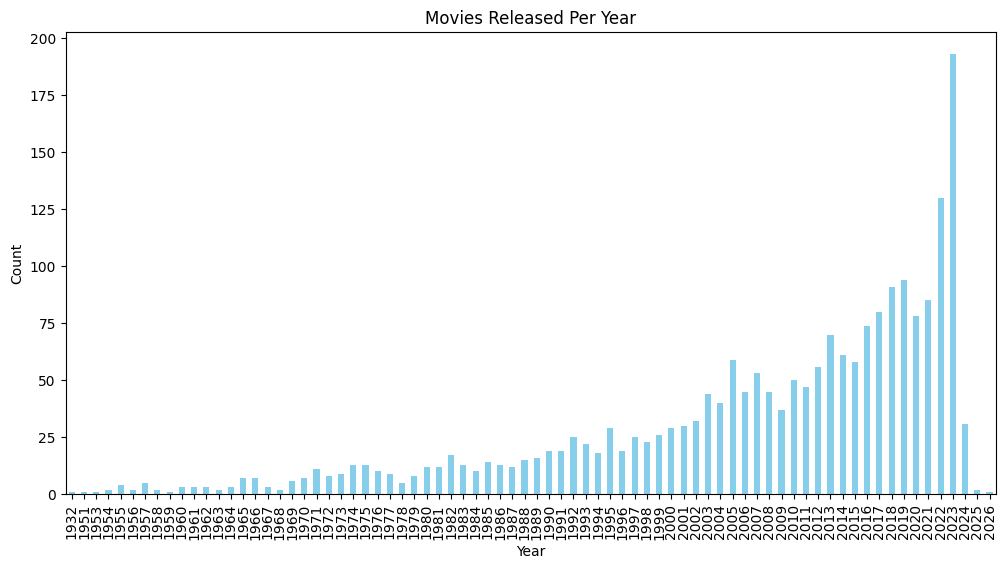

In [5]:
movies_per_year = df["year"].value_counts().sort_index()

plt.figure(figsize=(12,6))
movies_per_year.plot(kind="bar", color="skyblue")
plt.title("Movies Released Per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

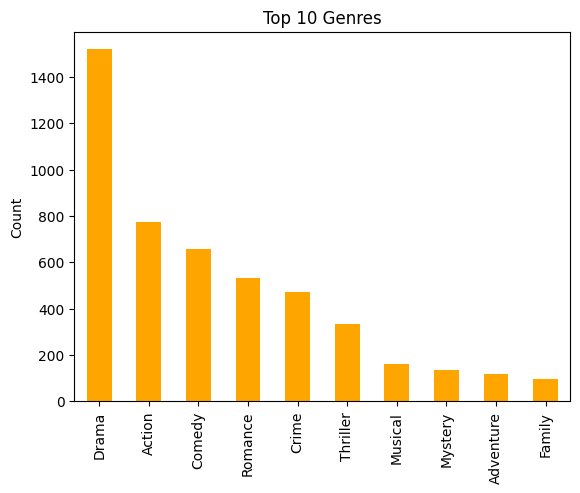

In [6]:
df["genre"] = df["genre"].fillna("")

all_genres = []

for genres in df["genre"]:
    all_genres.extend([g.strip() for g in genres.split(",")])

genre_counts = Counter(all_genres)

pd.Series(genre_counts).sort_values(ascending=False).head(10).plot(
    kind="bar", color="orange"
)

plt.title("Top 10 Genres")
plt.ylabel("Count")
plt.show()

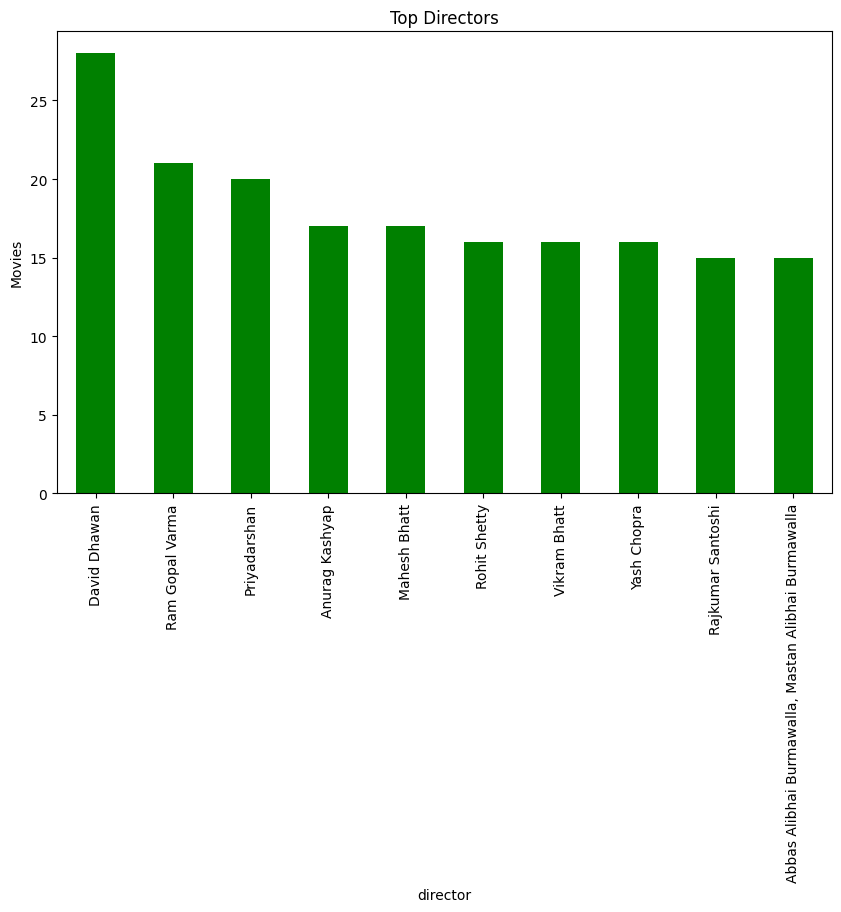

In [7]:
top_directors = df["director"].value_counts().head(10)

plt.figure(figsize=(10,6))
top_directors.plot(kind="bar", color="green")

plt.title("Top Directors")
plt.ylabel("Movies")
plt.show()

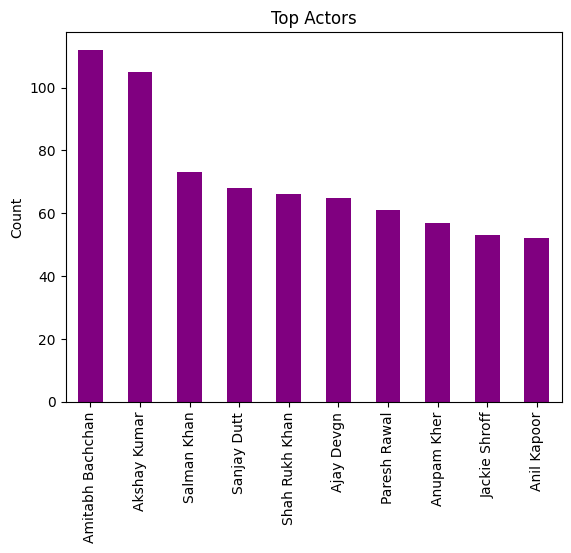

In [8]:
df["cast"] = df["cast"].fillna("")

all_actors = []

for cast_list in df["cast"]:
    all_actors.extend([actor.strip() for actor in cast_list.split(",")])

actor_counts = Counter(all_actors)

pd.Series(actor_counts).sort_values(ascending=False).head(10).plot(
    kind="bar", color="purple"
)

plt.title("Top Actors")
plt.ylabel("Count")
plt.show()

## Feature Engineering

In [9]:
df["combined_features"] = (
    df["genre"].fillna("") + " " +
    df["overview"].fillna("") + " " +
    df["director"].fillna("") + " " +
    df["cast"].fillna("")
)

## Vectorization

In [10]:
vectorizer = TfidfVectorizer(stop_words="english")

tfidf_matrix = vectorizer.fit_transform(df["combined_features"])

## Similarity Score

In [11]:
similarity_matrix = cosine_similarity(tfidf_matrix)

## Movie Reccomendation Logical Function

In [12]:
def recommend_movies(movie_title, top_n=5):

    movie_title = movie_title.lower()

    if movie_title not in df["movie_name"].str.lower().values:
        return "Movie not found in dataset"

    movie_index = df[df["movie_name"].str.lower() == movie_title].index[0]

    similarity_scores = list(enumerate(similarity_matrix[movie_index]))

    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)

    top_movies = similarity_scores[1:top_n+1]

    movie_indices = [i[0] for i in top_movies]

    return df[["movie_name","year","director"]].iloc[movie_indices]

In [14]:
recommend_movies("Jawan", top_n=5)

,movie_name,year,director
191,Happy New Year,2014,Farah Khan
8,Pathaan,2023,Siddharth Anand
53,Om Shanti Om,2007,Farah Khan
1659,Finding Fanny,2014,Homi Adajania
154,Chennai Express,2013,Rohit Shetty


## Movie Reccomendation Using description

In [15]:
def recommend_from_description(genre, overview, top_n=5):

    query = genre + " " + overview

    query_vec = vectorizer.transform([query])

    similarity_scores = cosine_similarity(query_vec, tfidf_matrix).flatten()

    top_indices = similarity_scores.argsort()[::-1][:top_n]

    return df[["movie_name","year","director"]].iloc[top_indices]

In [16]:
recommend_from_description(
    "Action Thriller",
    "Horror",
    5
)

,movie_name,year,director
1348,Raaz Reboot,2016,Vikram Bhatt
2035,Ragini MMS,2011,Pavan Kirpalani
956,Bramayugam,2024,Rahul Sadasivan
1639,Tamso,2023,Stephen Alexander
1621,Rosie: The Saffron Chapter,2022,Vishal Mishra
